In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [5]:
def sigmoid(x):
    return 1/(1 + np.exp(-(x)))
sigmoid(0)

np.float64(0.5)

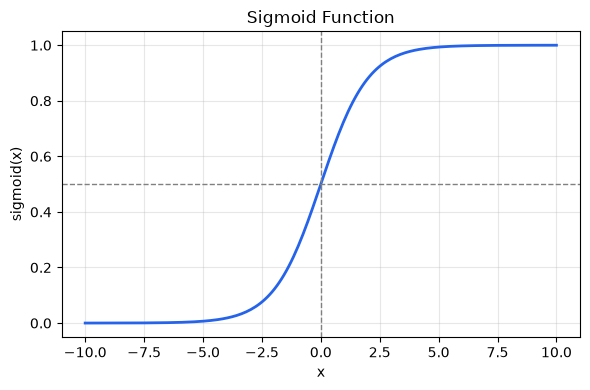

In [10]:
x_vals = np.linspace(-10, 10, 200)
plt.figure(figsize=(6, 4))
plt.plot(x_vals, sigmoid(x_vals), color='#2563eb', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
class LogisticRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            y_pred = self.predict(X)
            # print(X.shape, y_pred.shape, y.shape)
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum((y_pred - y))

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            eps = 1e-15
            y_pred_c = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(y * np.log(y_pred_c) + (1 - y) * np.log(1 - y_pred_c))
            self.loss_history.append(loss)
    
    def predict(self, X):
        # print(X.shape, self.weights.shape, (X * self.weights).shape)
        # y_pred = sigmoid(X @ self.weights + self.bias)
        y_pred = sigmoid((np.dot(X, self.weights) + self.bias))
        
        return y_pred


In [3]:
bc = datasets.load_breast_cancer()

X, y = bc.data, bc.target
y= y.flatten()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

X.shape, y.shape

((569, 30), (569,))

In [6]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

/var/folders/xz/grlvdj254l7259jt5kx3762c0000gn/T/ipykernel_64692/1734571490.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-(x)))


In [7]:
def accuracy(y_pred, y_test):
    class_pred = [0 if y<=0.5 else 1 for y in y_pred]
    return np.sum(class_pred==y_test)/len(y_test)

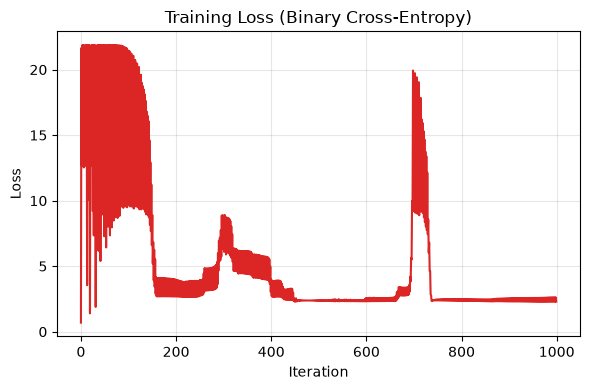

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(clf.loss_history, color='#dc2626', linewidth=1.5)
plt.title('Training Loss (Binary Cross-Entropy)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

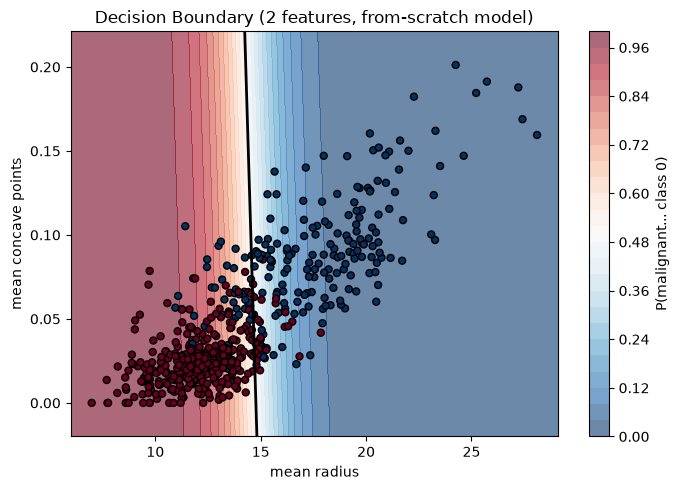

In [11]:
feat_x, feat_y = 'mean radius', 'mean concave points'
idx_x, idx_y = list(bc.feature_names).index(feat_x), list(bc.feature_names).index(feat_y)

X2 = X[:, [idx_x, idx_y]]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=1234)

clf_2d = LogisticRegression(lr=0.1, n_iters=3000)
clf_2d.fit(X2_train, y2_train)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300),
    np.linspace(X2[:, 1].min() - 0.02, X2[:, 1].max() + 0.02, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, probs, levels=25, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(malignant... class 0)')
plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=y, cmap='RdBu_r', edgecolor='k', s=25)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title('Decision Boundary (2 features, from-scratch model)')
plt.tight_layout()
plt.show()

In [94]:
accuracy(y_pred, y_test)

np.float64(0.8947368421052632)

In [84]:
np.sum([True, False, True])

np.int64(2)